# Árboles de decisión: Ejemplo

#### Una cooperativa de ahorro y crédito desea automatizar el proceso de evaluación de solicitudes de crédito de sus socios.
#### El análisis de aprobación se realiza considerando diferentes factores relacionados con el perfil del solicitante, como su nivel de ingresos, historial crediticio y nivel de endeudamiento
##### las variables son: Edad del solicitante, Ingreso mensual, Nivel de deuda actual, Puntaje de crédito, Historial crediticio

In [ ]:
# importamos librerias necesarias
import pandas as pd     #tranajar datasets
import matplotlib.pyplot as plt     # graficar 
from sklearn.model_selection import train_test_split  # División de datos
from sklearn.tree import DecisionTreeClassifier, plot_tree   # Modelo de Árbol de Decisión
from sklearn.preprocessing import LabelEncoder   # Codificación de variables categóricas
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Métricas de evaluación

In [2]:
# Cargar dataset
df = pd.read_csv("datasetarbol_credito.csv")
df.head()

,Edad,Ingreso_mensual,Deuda_actual,Puntaje_credito,Historial_crediticio,Credito_aprobado
0,59,4974,1908,447,Regular,Si
1,49,4267,375,766,Bueno,Si
2,35,1825,3530,543,Regular,No
3,63,6745,1160,790,Malo,No
4,28,2516,2635,806,Bueno,No


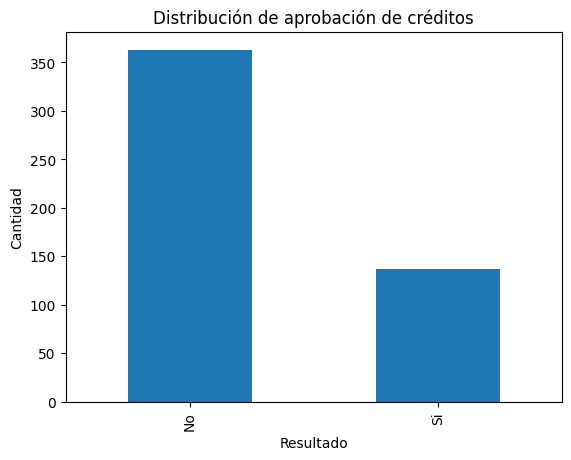

In [ ]:
# VISUALIZAR LA VARIABLE OBJETIVO (Credito_aprobado)

plt.figure()

df["Credito_aprobado"].value_counts().plot(kind="bar")

plt.title("Distribución de aprobación de créditos")
plt.xlabel("Resultado")
plt.ylabel("Cantidad")

plt.show()

In [ ]:
# CONVERSIÓN DE LAS VARIABLES CATEGÓRICAS
# df.dtypes (para ver que variables son string y hay que transformarlas)

# Crear codificadores
le_historial = LabelEncoder()
le_credito = LabelEncoder()

# Convertir historial crediticio a números (bueno=0, recgular=1, malo=2)
df["Historial_crediticio"] = le_historial.fit_transform(df["Historial_crediticio"])

# Convertir variable objetivo (no = 0, si = 1)
df["Credito_aprobado"] = le_credito.fit_transform(df["Credito_aprobado"])

In [ ]:
# separa variable predictoras y objetivo
# Variables predictoras
X = df.drop("Credito_aprobado", axis=1)

# Variable objetivo
y = df["Credito_aprobado"]

In [ ]:
# DIVISION DEL DATA SET
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.3,
    random_state=42
)

In [10]:
# Entrenamiento del modelo de Árbol de Decisión
# Crear modelo
modelo = DecisionTreeClassifier(

    criterion="gini",
    max_depth=4,
    random_state=42
)

# Entrenar modelo
modelo.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

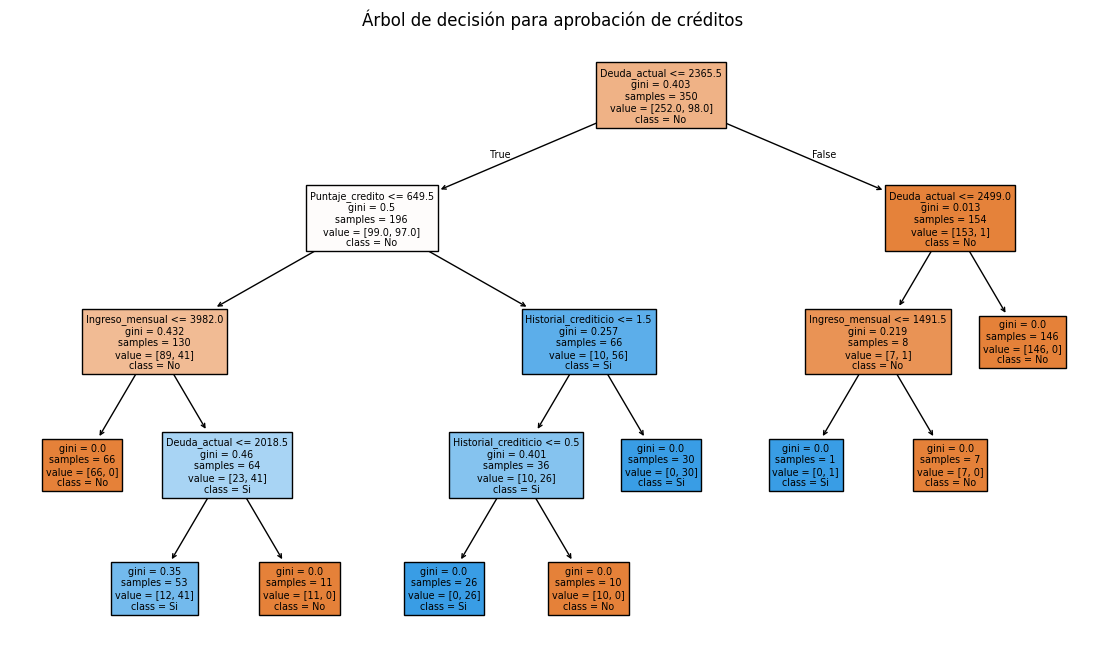

In [11]:
# VISUALIZACIÓN DE ARBOL

plt.figure(figsize=(14,8))

plot_tree(

    modelo,
    feature_names=X.columns,
    class_names=["No","Si"],
    filled=True
)

plt.title("Árbol de decisión para aprobación de créditos")

plt.show()

In [ ]:
# importancia de variables
importancias = modelo.feature_importances_

importancia_df = pd.DataFrame({

    "Variable": X.columns,
    "Importancia": importancias

}).sort_values(by="Importancia", ascending=False)

print(importancia_df)

               Variable  Importancia
2          Deuda_actual     0.426611
1       Ingreso_mensual     0.231895
3       Puntaje_credito     0.203026
4  Historial_crediticio     0.138467
0                  Edad     0.000000


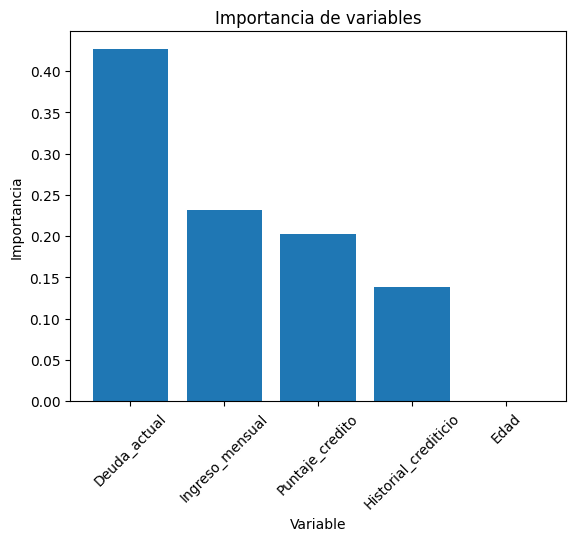

In [ ]:
# grafico de la importancia de las variables
plt.figure()

plt.bar(importancia_df["Variable"], importancia_df["Importancia"])

plt.title("Importancia de variables")
plt.xlabel("Variable")
plt.ylabel("Importancia")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# PREDICCION DEL MODELO 

y_pred = modelo.predict(X_test)

In [ ]:
# Evaluación del modelo qué porcentaje de predicciones fueron correctas
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy del modelo:", accuracy)

Accuracy del modelo: 0.96


In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

print("Matriz de confusión:")
print(cm)

Matriz de confusión:
[[106   5]
 [  1  38]]


In [ ]:
# print(classification_report(y_test, y_pred))